In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns



In [50]:
df = pd.read_csv("cleaned_utah.csv")
df = df.drop(columns=["Unnamed: 0","listPrice"], errors="ignore")
df = df.dropna(subset=["property_type"])


label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["property_type"])


for col in df.columns:
    if col != "property_type":
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

X = df.select_dtypes(include=np.number).drop(columns=["label"]).dropna()
y = df.loc[X.index, "label"]


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [69]:
X_train.head()


,year_built,beds,baths,baths_full,garage,sqft,stories
331,2003,3,3,2,2,3120,2
409,2003,4,0,2,2,2400,2
76,2003,4,3,2,2,1615,2
868,2003,4,0,2,2,2400,2
138,2003,3,3,2,2,1480,2


In [66]:
X_test.head()

,year_built,beds,baths,baths_full,garage,sqft,stories
1178,1999,5,3,2,2,2341,2
865,2003,4,0,2,2,2400,2
101,2003,4,0,2,2,2400,2
439,1983,4,2,2,2,2196,2
58,2003,4,3,2,2,2553,2


In [70]:
X_test.to_csv("X_test.csv")

In [71]:
y_train.head()

,label
331,1
409,1
76,0
868,0
138,0


In [72]:
y_train.to_csv("y_train.csv")

In [75]:

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


print("Scaled X_train:")
print(X_train_scaled_df.head())




Scaled X_train:
     year_built      beds     baths  baths_full  garage      sqft  stories
331     -0.1054 -1.314135  1.412328         0.0     0.0  2.457143      0.0
409     -0.1054  0.560411 -0.778035         0.0     0.0  0.431448      0.0
76      -0.1054  0.560411  1.412328         0.0     0.0 -1.777122      0.0
868     -0.1054  0.560411 -0.778035         0.0     0.0  0.431448      0.0
138     -0.1054 -1.314135  1.412328         0.0     0.0 -2.156940      0.0


In [77]:
X_train_scaled_df.to_csv("X_train_scaled_df.csv")

In [76]:
print("\nScaled X_test:")
print(X_test_scaled_df.head())


Scaled X_test:
      year_built      beds     baths  baths_full  garage      sqft  stories
1178   -1.104745  2.434957  1.412328         0.0     0.0  0.265453      0.0
865    -0.105400  0.560411 -0.778035         0.0     0.0  0.431448      0.0
101    -0.105400  0.560411 -0.778035         0.0     0.0  0.431448      0.0
439    -5.102125  0.560411  0.682207         0.0     0.0 -0.142499      0.0
58     -0.105400  0.560411  1.412328         0.0     0.0  0.861908      0.0


In [78]:
X_test_scaled_df.to_csv("X_test_scaled_df.csv")

In [73]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
ab = AdaBoostClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42)

rf.fit(X_train_scaled, y_train)
ab.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
ab_pred = ab.predict(X_test_scaled)
xgb_pred = xgb.predict(X_test_scaled)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:45:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [54]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


Random Forest Classification Report:
               precision    recall  f1-score   support

  Affordable       0.85      0.97      0.91       146
     Average       0.80      0.65      0.72        72
      Luxury       0.64      0.41      0.50        22

    accuracy                           0.82       240
   macro avg       0.76      0.68      0.71       240
weighted avg       0.82      0.82      0.81       240



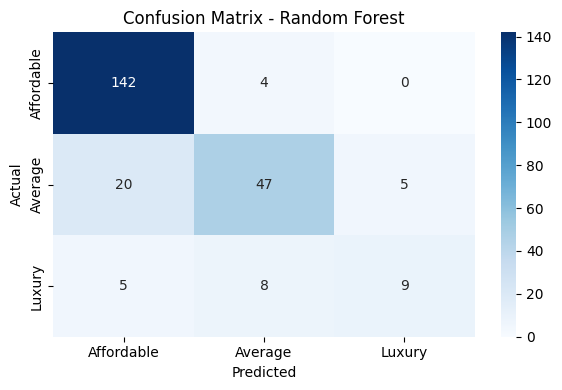

In [56]:

print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred, target_names=label_encoder.classes_))
plot_conf_matrix(y_test, rf_pred, "Random Forest")





AdaBoost Classification Report:
               precision    recall  f1-score   support

  Affordable       0.83      0.92      0.87       146
     Average       0.65      0.69      0.67        72
      Luxury       0.00      0.00      0.00        22

    accuracy                           0.77       240
   macro avg       0.49      0.54      0.51       240
weighted avg       0.70      0.77      0.73       240



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


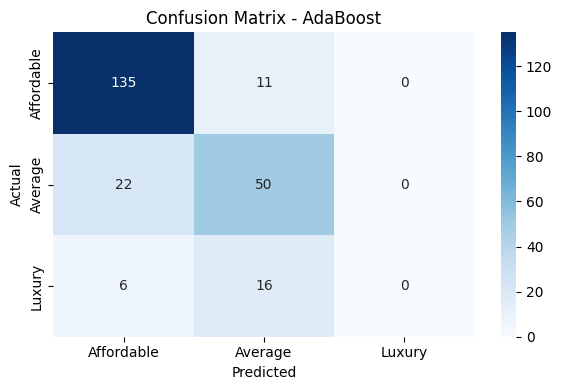

In [57]:

print("\nAdaBoost Classification Report:\n", classification_report(y_test, ab_pred, target_names=label_encoder.classes_))
plot_conf_matrix(y_test, ab_pred, "AdaBoost")




XGBoost Classification Report:
               precision    recall  f1-score   support

  Affordable       0.85      0.97      0.90       146
     Average       0.77      0.64      0.70        72
      Luxury       0.50      0.32      0.39        22

    accuracy                           0.81       240
   macro avg       0.71      0.64      0.66       240
weighted avg       0.79      0.81      0.79       240



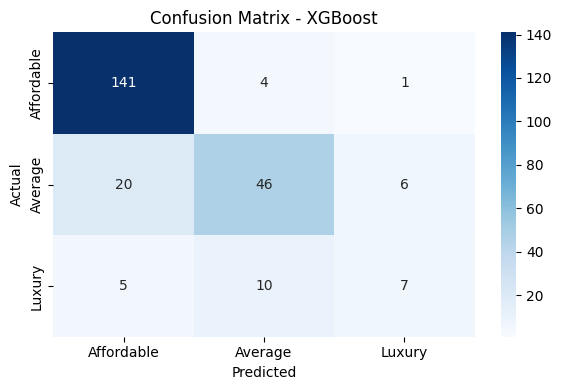

In [58]:

print("\nXGBoost Classification Report:\n", classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))
plot_conf_matrix(y_test, xgb_pred, "XGBoost")

In [59]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision (macro)": round(precision_score(y_true, y_pred, average='macro'), 4),
        "Recall (macro)": round(recall_score(y_true, y_pred, average='macro'), 4),
        "F1 Score (macro)": round(f1_score(y_true, y_pred, average='macro'), 4)
    }

comparison_results = [
    evaluate_model("Random Forest", y_test, rf_pred),
    evaluate_model("AdaBoost", y_test, ab_pred),
    evaluate_model("XGBoost", y_test, xgb_pred)
]

comparison_df = pd.DataFrame(comparison_results)
print("\nModel Comparison:\n", comparison_df)



Model Comparison:
            Model  Accuracy  Precision (macro)  Recall (macro)  \
0  Random Forest    0.8250             0.7633          0.6782   
1       AdaBoost    0.7708             0.4925          0.5397   
2        XGBoost    0.8083             0.7054          0.6409   

   F1 Score (macro)  
0            0.7083  
1            0.5150  
2            0.6632  


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1000x600 with 0 Axes>

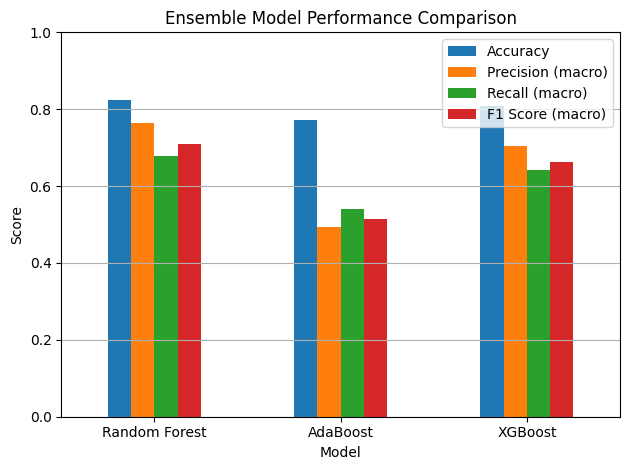

In [60]:
plt.figure(figsize=(10, 6))
comparison_df.set_index("Model")[["Accuracy", "Precision (macro)", "Recall (macro)", "F1 Score (macro)"]].plot(kind="bar")
plt.title("Ensemble Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [61]:
def plot_top_features(model, feature_names, model_name, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]  # Top n features
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
    plt.title(f"Top {top_n} Features - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


<ipython-input-61-238cad0d1cd6>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


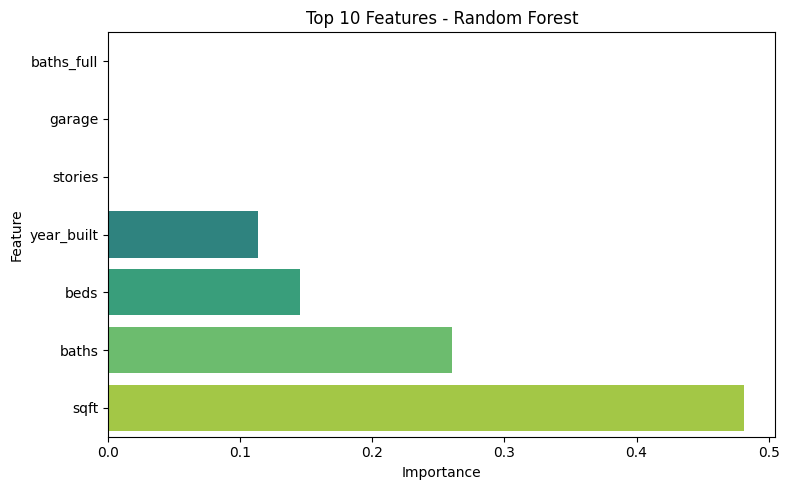

In [62]:
# Make sure to pass the original feature names (before scaling)
feature_names = X.columns

# Random Forest
plot_top_features(rf, feature_names, "Random Forest")




<ipython-input-61-238cad0d1cd6>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


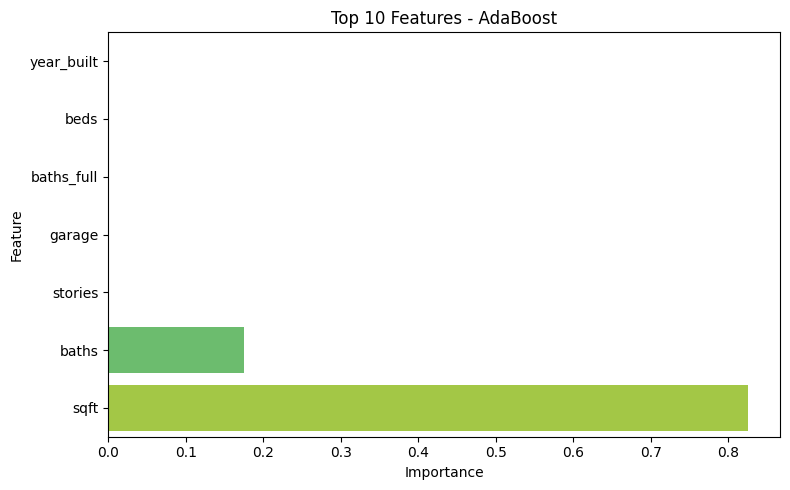

In [63]:
# AdaBoost
plot_top_features(ab, feature_names, "AdaBoost")



<ipython-input-61-238cad0d1cd6>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


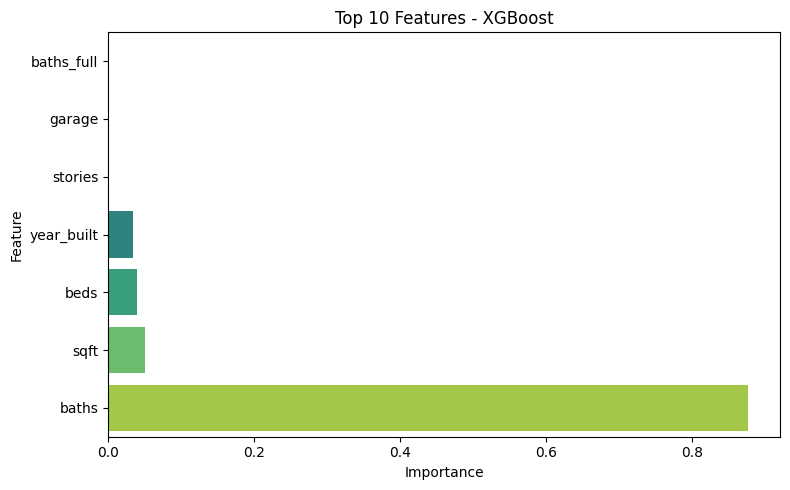

In [64]:
# XGBoost
plot_top_features(xgb, feature_names, "XGBoost")